### 📈 Curvature Optimization

Once the spline is built:
- You must **replace the assumed boundary conditions** (like natural spline: second derivative = 0 at endpoints).
- Your goal is to **optimize** the spline such that the **total curvature is minimized**.
- This will result in a **smoother path**—which is desirable for autonomous vehicle trajectory planning.


### 🔍 What does Optimization mean here?
There are 3 parts to an optimization problem:
- Objective (or Cost) Function :
This is the function you want to minimize or maximize.
- Parameters (or Decision Variables):
These are the variables you are allowed to change in order to achieve the best value of the objective.
- Constraints:
These are the rules or limits that the parameters and/or the solution must satisfy.
In general, optimization means adjusting parameters to minimize or maximize an objective — like reducing cost, increasing speed, or in our case: minimizing curvature.

Here, you are given 4 fixed waypoints. Your goal is to interpolate these points using cubic splines, but with a twist:

refer to the first 3 videos of the following playlist for a better understanding:
[Video: Introduction to Curve Optimization](https://youtube.com/playlist?list=PLLK3oSbvdxFdF67yVxF_1FQO9SbBY3yTL&si=EMnkQ3Gb_EleDISu)

---
## 🎯 PROBLEM STATEMENT
You are given 4 discrete waypoints from the previous section. Your task is to interpolate these points using **cubic spline interpolation**, but with a focus on **optimizing the shape of the curve**.

Essentially, you are required to **minimize the total curvature** of the resulting spline by **varying the second derivative values at the boundaries**. This should be done **without using inbuilt spline functions** from libraries such as `scipy`. The goal is to find the **smoothest possible path** through the points, which would represent the **ideal trajectory** for a vehicle to follow. You may choose suitable bounds for the second derivative values and iterate through different combinations of boundary conditions to determine the configuration that leads to the **minimum total curvature**.

---

## Curvature Formula

The **curvature** $\kappa(t)$ of a 2D parametric curve $(x(t), y(t))$ is given by:

$$
\kappa(t) = \frac{ |x'(t)y''(t) - y'(t)x''(t)| }{ \left( (x'(t))^2 + (y'(t))^2 \right)^{3/2} }
$$

Where:
- $x'(t)$ and $y'(t)$ are the **first derivatives** with respect to the parameter $t$
- $x''(t)$ and $y''(t)$ are the **second derivatives**

---

## 📌 Deliverables

1. Your own implementation of cubic spline interpolation.
2. Plots of:
   - Original points
   - Interpolated spline without optimization
   - Interpolated spline with optimization
---

### 🌟 Optional Assignement

You may notice that directly finding the smoothest curve through waypoints seems inefficient and computationally expensive. Fortunately, mathematicians have developed robust optimization techniques that are readily available through libraries like `scipy.optimize`.

In this task, try enhancing the **cubic interpolation curve** you obtained earlier by finding an **optimal trajectory through the waypoints** — one that minimizes the curvature at every interpolated point. To do this, you can treat the **second derivatives at the curve’s boundaries** as variables to be optimized. Use `scipy` functions to perform this optimization and compare the resulting smooth curve to the original interpolation.

However, you may not notice an appreciable reduction in sharpness and a smoother, more natural path. What else can be done then for the **optimal raceline** for our car?

---

**Good luck!**  Let the paths be smooth and the math be satisfying!

In [18]:
import matplotlib.pyplot as plt
import numpy as np

In [54]:
n=3
points=np.array([[1,4],[3,8],[6,6],[9,10]])
def path(points,a,b):
    spline= np.zeros((4,n)) # array of coeffs
    for i in range(n): # y= a(x-xi)^3 +b(x-xi)^2 +c(x-xi) +d
        spline[3,i]=points[i,1] # d=yi at x=xi
    A = np.zeros((3*n,3*n))
    B = np.zeros(3*n) 
    A[0,1]=2
    A[1,(3*n-3)]=6*(points[n,0]-points[n-1,0])
    A[1,(3*n-2)]=2
    B[0]=a
    B[1]=b
    for i in range(n):
        j=3*i
        h = points[i+1,0]-points[i,0]
        A[i+2,j]=h**3
        A[i+2,j+1]=h**2
        A[i+2,j+2]=h
        B[i+2]=points[i+1,1]-spline[3,i]
    for i in range(n-1):
        j=3*i
        h = points[i+1,0]-points[i,0]
        A[i+n+2,j]=(h**2)*3
        A[i+n+2,j+1]=h*2   
        A[i+n+2,j+2]=1
        A[i+n+2,j+5]=-1
    for i in range(n-1):
        j=3*i
        h = points[i+1,0]-points[i,0]
        A[i+2*n+1,j]=h*3
        A[i+2*n+1,j+1]=1
        A[i+2*n+1,j+4]=-1    
    coeff=np.linalg.solve(A,B) 
    x=np.array(coeff)  
    for i in range(n):
        j=3*i
        spline[0,i]=x[j]
        spline[1,i]=x[j+1]
        spline[2,i]=x[j+2]   
    return spline     

In [ ]:
#optimisation part

def cost(spline,points):
    j=0
    for i in range(n):
        u = np.linspace(points[i,0],points[i+1,0],100)
        du = u[1]-u[0]
        xi = points[i,0]
        k=(((6*(u-xi)*spline[0,i] + 2*spline[1,i])**2)/(1+(3*spline[0,i]*((u-xi)**2) + 2*spline[1,i]*(u-xi) + spline[2,i])**2)**3)
        j+= np.sum(k)*du # integral k^2.du
    return j
lr=0.5 # learning rate
h = 1e-5 # small h value for partial derivative
a=0
b=0
for i in range(100):
        spline = path(points,a,b)
        J = cost(spline,points)
        Ja = cost(path(points,a+h,b),points)
        ga = (Ja - J)/h
        Jb = cost(path(points,a,b+h),points)
        gb = (Jb - J)/h
        a = a - lr*ga
        b = b - lr*gb
        print(i,J,a,b) # printing J to optimise lr value
spline_final = path(points,a,b) 

0 3.410155848379043 -0.09181573106253892 0.17534463820911836
1 3.333222597322883 -0.18341342720162854 0.34249247791162674
2 3.262070523529226 -0.27492184220267996 0.5004664130225933
3 3.196950005406258 -0.36643624359289356 0.6484973316123188
4 3.1378866179579497 -0.45801657007071833 0.7860949053695165
5 3.084681019305901 -0.5496895746359697 0.9130596561934823
6 3.0369511446560837 -0.6414533795684462 1.0294579385394798
7 2.994192139227171 -0.7332829925044136 1.1355766867726658
8 2.955836742378963 -0.8251357161315197 1.2318705892910842
9 2.9213060597306697 -0.9169558244037644 1.3189103179378492
10 2.8900466711892925 -1.0086782503249123 1.397336867592358
11 2.861554116716581 -1.1002312837904424 1.467824266576656
12 2.8353849915666434 -1.1915384116045755 1.5310510137478417
13 2.8111606280087447 -1.2825194873222754 1.5876794815294915
14 2.788565209859918 -1.3730914178999851 1.638342007970195
15 2.767340632451716 -1.463168532422898 1.6836322769719914
16 2.747279790082687 -1.5526627643369648 

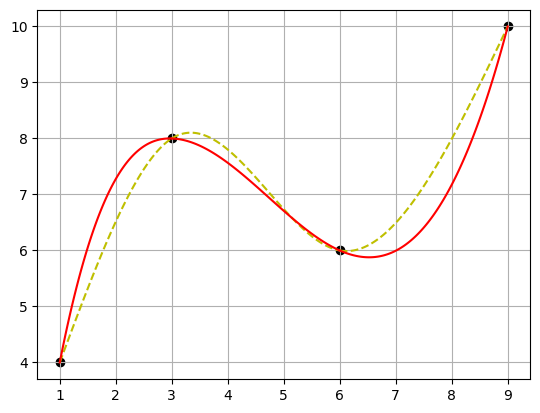

In [56]:
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.scatter(points[:,0], points[:,1], marker='o',c='black')
plt.grid(True)
spline=path(points,0,0)
for i in range(n):
    v = np.linspace(points[i,0], points[i+1,0], 100)
    xi = points[i,0]
    y = spline[0,i]*(v-xi)**3 + spline[1,i]*(v-xi)**2 +spline[2,i]*(v-xi) + spline[3,i]
    ax.plot(v,y,'y--')
    y_final=spline_final[0,i]*(v-xi)**3 + spline_final[1,i]*(v-xi)**2 +spline_final[2,i]*(v-xi) + spline_final[3,i]
    ax.plot(v,y_final,'r')
plt.show()